# Resnet18 Final Balanced Retrieval Model

This notebook keeps notebook 6's late-fusion ResNet18 backbone, but turns it into the final balanced model: cross-song structure is defined by an even blend of frozen audio similarity and tag similarity, using the same PNG spectrogram injection path as notebook 6.


## Notes
 - Train on `data/processed/train.parquet`, retrieve on `data/processed/val.parquet`.
 - Unlike notebooks 4-6, the cross-song teacher is now balanced: a new frozen PNG-based audio teacher contributes `50%` of the target, and the tag teacher carried over from notebooks 4-6 contributes the other `50%` when available.
 - Injection stays on resized PNG spectrograms, following notebook 6's data path.
 - The small InfoNCE term is now same-song paired-view alignment on the song embedding itself. In notebook 6 it aligned mix and harmonic views from the same forward pass.
 - The final model keeps the familiar input pipeline while shifting the supervision toward a balanced audio-semantic notion of similarity.


## Flow

1. Load the processed train/validation splits.
2. Build two frozen teachers:
   - the tag-teacher tag sets carried over from notebooks 4-6,
   - a new compact PNG-based audio teacher built directly inside notebook 7.
3. Sample paired augmented PNG spectrogram views for each training song.
4. Encode mix + stems with the same late-fusion ResNet18 used in notebook 6.
5. Train the song embedding against a 50/50 audio-tag blended cross-song target, plus light audio consistency losses.
6. Encode the validation split with the same PNG injection path used in notebook 6.
7. Retrieve held-out neighbors by cosine similarity and save the run artifacts.


## System Flowchart (High Level)

```text
[PNG spectrogram views: mix + stems]       [New frozen PNG-based audio teacher]
               |                                              |
               v                                              v
        [Shared ResNet18]                           [Compact audio teacher vectors]
           /          \                                         |
          v            v                                        |
  [Crop A embedding] [Crop B embedding]                         |
          \            /                                        |
           v          v                                         v
       [Late Fusion song embedding]                [Batch audio-similarity matrix]
                    |
                    |                  [Frozen tag-teacher vectors (as used in notebooks 4-6)]
                    |                                |
                    v                                v
        [Blended 50% audio / 50% tag target similarity]
                    |
                    v
    [Cross-song teacher loss] + [view alignment] + [crop-to-crop InfoNCE]
                    |
                    v
             [Validation retrieval by cosine]
```

## 1) Environment Setup

Import the libraries and project helpers used throughout the notebook.


In [17]:
from __future__ import annotations

import json
import sys
from pathlib import Path
import random
from datetime import datetime
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from torchvision.models import ResNet18_Weights, resnet18


ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "src").exists() and ROOT_DIR.parent.exists():
    ROOT_DIR = ROOT_DIR.parent
SRC_DIR = ROOT_DIR / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from song_recommender.paths import DATA_DIR, TAG_CLUSTER_MAP, TAG_KEYS, TAG_VECTORS, VALID_TAGS
from song_recommender.data.indexer import TrackIndexer
from song_recommender.data.loader import load_png_resized
from song_recommender.features.tag_features import clean_tags


## 2) Hyperparameters (Main Control Panel)

Most experiment changes happen in `CFG`. Keep the notebook logic fixed and edit this cell when you want a new run.


## 2b) What Changed From Notebook 6

- Kept the same late-fusion ResNet18 architecture, retrieval flow, and artifact-saving pattern as notebook 6.
- Replaced notebook 6's pure tag-relational cross-song teacher with a blended teacher: `50%` compact frozen audio similarity and `50%` tag-teacher similarity from the setup used in notebooks 4-6.
- Switched training inputs from full-song PNG spectrograms to raw spectrogram time crops. Notebooks 4-6 trained on resized full-song PNGs.
- Changed the small InfoNCE term from mix-vs-harmonic alignment to crop-vs-crop song-level alignment, which is more directly audio-centric.
- Added lightweight dominant-cluster batch grouping so tags mainly create harder within-style batches instead of being the primary supervision signal.
- Reduced the extra regularization weights so the new blended cross-song objective stays dominant.

In [18]:
# =========================
# Config (edit this cell)
# =========================
CFG = {
    "experiment_name": "07_Resnet18_audio_centric_blended_teacher",
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",

    # Data
    "image_size": 224,
    "audio_teacher_image_size": 48,
    "train_crop_width": 256,
    "batch_size": 48,
    "num_workers": 0,
    "train_use_two_crops": True,
    "cluster_group_batching": True,

    # Optimization
    "num_epochs": 80,
    "max_steps_per_epoch": None,
    "learning_rate": 8e-5,
    "weight_decay": 1e-5,
    "grad_clip_norm": 1.0,

    # Model
    "embedding_dim": 64,
    "projection_dim": 128,
    "pretrained": True,
    "stem_dropout_prob": 0.05,
    "fusion_alpha_init": 0.75,
    "drum_alpha_init": 0.20,

    # Augmentation
    "aug_enabled_train": True,
    "aug_pitch_shift_bins": 2,
    "aug_time_scale_range": (0.98, 1.02),
    "aug_gain_range": (0.98, 1.02),
    "aug_noise_std": 0.005,
    "aug_mask_prob": 0.15,
    "aug_max_mask_width": 8,
    "aug_one_second_dropout_prob": 0.03,
    "aug_one_second_width": 22,

    # Losses
    "audio_teacher_weight": 0.50,
    "tag_teacher_weight": 0.50,
    "lambda_cross_alignment": 1.0,
    "lambda_view_alignment": 0.20,
    "lambda_instance_nce": 0.10,
    "nce_temperature": 0.10,
    "drum_view_weight": 0.40,

    # Teacher logging
    "audio_teacher_log_every": 500,

    # Query + optional rerank
    "query_spotify_id": "5kgvRTKmoJChOc5PAdHZg3",
    "example_query_count": 3,
    "example_top_k": 5,
    "rerank_tag_weight": 0.0,
    "rerank_year_weight": 0.0,
    "rerank_artist_repeat_penalty": 0.0,

    # Training logging
    "batch_logs_per_epoch": 2,

    # Quick metric evaluation
    "metrics_max_queries": 2000,
    "metrics_sample_seed": 42,

    # Output
    "run_label": "07_Resnet18_audio_centric_blended_teacher",
}

OUTPUT_DIR = (DATA_DIR / "processed" / "model_runs" / CFG["run_label"]).resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("experiment:", CFG["experiment_name"])
print("device:", CFG["device"])
print("output_dir:", OUTPUT_DIR)


experiment: 07_Resnet18_audio_centric_blended_teacher
device: cuda
output_dir: C:\Users\Juan\Documents\GitHub\dl-song-recommender\data\processed\model_runs\07_Resnet18_audio_centric_blended_teacher


In [19]:
def set_seed(seed: int) -> None:
    """Set random seeds for reproducible experiments."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def mean_or_nan(values) -> float:
    return float(np.mean(values)) if values else np.nan


set_seed(CFG["seed"])
device = torch.device(CFG["device"])


## 3) Split Load

Load the processed train/validation splits and derive `clean_tags` once at load time.

- `train_df` drives optimization.
- `val_df` is used only for retrieval and quick checks.
- `clean_tags` comes from the processed `tag_list` plus the same valid tag vocabulary used in notebooks 4-6.

The train/validation split itself is the leakage boundary. This notebook keeps that boundary intact by training only on `train_df` and using `val_df` only after training for held-out embedding build and evaluation.


In [20]:
valid_tags = set(json.loads(VALID_TAGS.read_text()))
# Split loading stays simple: read the processed frame, then derive clean tags once.


def load_split_df(split_name: str) -> pd.DataFrame:
    frame = pd.read_parquet(DATA_DIR / "processed" / f"{split_name}.parquet").copy()
    frame["clean_tags"] = frame["tag_list"].apply(lambda tags: clean_tags(tags, valid_tags))
    return frame


train_df = load_split_df("train")
val_df = load_split_df("val")

train_indexer = TrackIndexer(train_df)
val_indexer = TrackIndexer(val_df)
# These checks protect the assumptions used later by the stem branches and the holdout evaluation.
split_overlap = len(set(train_df["spotify_id"]) & set(val_df["spotify_id"]))
assert split_overlap == 0, "train/validation splits must be disjoint"
expected_stem_order = ['bass', 'drums', 'other', 'vocals']
assert train_indexer.stem_list == expected_stem_order, f"unexpected train stem order: {train_indexer.stem_list}"
assert val_indexer.stem_list == expected_stem_order, f"unexpected validation stem order: {val_indexer.stem_list}"

print("train songs:", len(train_df))
print("val songs:", len(val_df))
print("train/val overlap:", split_overlap)
print("stem order:", ["full mix"] + train_indexer.stem_list)

train_df[["spotify_id", "clean_tags"]].head(3)


train songs: 8102
val songs: 1447
train/val overlap: 0
stem order: ['full mix', 'bass', 'drums', 'other', 'vocals']


,spotify_id,clean_tags
0,0dnz7bSs3txd9nGY9e3Mlf,"[classic_rock, hard_rock, 80s, progressive_rock]"
1,0a5wz1j3rnDa6IawNoZp5C,"[classic_rock, hard_rock, british, blues, psyc..."
2,0zWtqc7q1JrB1gKyI501ph,"[classic_rock, 70s, oldies, blues_rock]"


## 4) Frozen Teachers from Notebooks 4-6 Plus a New Audio Teacher

Notebook 7 keeps the semantic tag teacher used in notebooks 4-6, but it no longer stands alone.

For each training song we now prepare two frozen teacher views:
1. a tag-teacher tag set, exactly as in notebooks 4-6,
2. a new compact audio teacher built from the same PNG spectrogram injection path used by the training model.

The cross-song target is blended as:

$$
T_{ij} = 0.50 \, S_{\mathrm{audio}}(A_i, A_j) + 0.50 \, S_{\mathrm{tag}}(E_i, E_j)
$$

when both songs have semantic teachers. If a tag teacher is missing, notebook 7 falls back to the audio teacher for that pair instead of dropping the pair entirely.

So section 4 is not redoing the semantic-teacher work from earlier notebooks. It reuses that machinery, then adds a separate frozen audio teacher so notebook 7 can balance sonic and semantic structure.


In [21]:
tag_keys = json.loads(TAG_KEYS.read_text())
tag_vectors = torch.as_tensor(np.load(TAG_VECTORS).astype(np.float32), device=device)
tag_vectors = F.normalize(tag_vectors, dim=1, eps=1e-8)
tag_vector_map = dict(zip(tag_keys, tag_vectors))
empty_tag_matrix = torch.empty((0, tag_vectors.shape[1]), device=device)
tag_cluster_map = json.loads(TAG_CLUSTER_MAP.read_text())


def keep_embedded_tags(tags: list[str]) -> list[str]:
    # Keep tag order, but drop duplicates so one repeated tag does not get extra weight.
    return [tag for tag in dict.fromkeys(tags) if tag in tag_vector_map]


def build_semantic_tag_matrix(tags: list[str]) -> tuple[torch.Tensor, bool]:
    tags = keep_embedded_tags(tags)
    if not tags:
        return empty_tag_matrix.clone(), False
    return torch.stack([tag_vector_map[tag] for tag in tags], dim=0), True


def dominant_cluster_from_tags(tags: list[str]):
    clusters = [tag_cluster_map[tag] for tag in tags if tag in tag_cluster_map]
    if not clusters:
        return None
    return Counter(clusters).most_common(1)[0][0]


def prepare_semantic_tag_sets(frame: pd.DataFrame):
    frame = frame.copy()
    frame["clean_tags"] = frame["clean_tags"].apply(keep_embedded_tags)

    track_id_to_tag_matrix = {}
    track_id_has_semantic_teacher = {}
    for track_id, tags in frame[["spotify_id", "clean_tags"]].itertuples(index=False):
        tag_matrix, has_teacher = build_semantic_tag_matrix(list(tags))
        track_id_to_tag_matrix[track_id] = tag_matrix
        track_id_has_semantic_teacher[track_id] = has_teacher

    frame["has_semantic_teacher"] = frame["spotify_id"].map(track_id_has_semantic_teacher)
    frame["dominant_cluster"] = frame["clean_tags"].apply(dominant_cluster_from_tags)
    return frame, track_id_to_tag_matrix, track_id_has_semantic_teacher


def build_audio_teacher_vector(spec_path_list, image_size: int) -> np.ndarray:
    # Compact PNG-based baseline embedding for the frozen audio teacher.
    chans = [load_png_resized(str(path), image_size=image_size) for path in spec_path_list]
    x = np.stack(chans, axis=0).astype(np.float32).reshape(-1)
    x = x / max(float(np.linalg.norm(x)), 1e-8)
    return x.astype(np.float16)


def build_audio_teacher_map(frame: pd.DataFrame, image_size: int, log_every: int | None = 500):
    indexer = TrackIndexer(frame)
    track_id_to_audio_teacher = {}
    total = len(frame)
    for i, track_id in enumerate(frame["spotify_id"].tolist()):
        if log_every and i % log_every == 0:
            print(f"audio teacher {i + 1}/{total}")
        spec_paths = indexer.get_spec_png_paths(track_id)
        track_id_to_audio_teacher[track_id] = build_audio_teacher_vector(spec_paths, image_size=image_size)
    return track_id_to_audio_teacher


train_df, train_track_id_to_tag_matrix, train_track_id_has_semantic_teacher = prepare_semantic_tag_sets(train_df)
val_df, _, _ = prepare_semantic_tag_sets(val_df)
train_track_id_to_audio_teacher = build_audio_teacher_map(
    train_df,
    image_size=CFG["audio_teacher_image_size"],
    log_every=CFG["audio_teacher_log_every"],
)

print("semantic teacher dim:", tag_vectors.shape[1])
print("audio teacher dim:", len(next(iter(train_track_id_to_audio_teacher.values()))))
print("train tracks with semantic teacher:", int(train_df["has_semantic_teacher"].sum()), "/", len(train_df))
print("val tracks with semantic teacher:", int(val_df["has_semantic_teacher"].sum()), "/", len(val_df))
print("train tracks with dominant tag cluster:", int(train_df["dominant_cluster"].notna().sum()), "/", len(train_df))

train_df[["spotify_id", "clean_tags", "has_semantic_teacher", "dominant_cluster"]].head(3)


audio teacher 1/8102
audio teacher 501/8102
audio teacher 1001/8102
audio teacher 1501/8102
audio teacher 2001/8102
audio teacher 2501/8102
audio teacher 3001/8102
audio teacher 3501/8102
audio teacher 4001/8102
audio teacher 4501/8102
audio teacher 5001/8102
audio teacher 5501/8102
audio teacher 6001/8102
audio teacher 6501/8102
audio teacher 7001/8102
audio teacher 7501/8102
audio teacher 8001/8102
semantic teacher dim: 64
audio teacher dim: 11520
train tracks with semantic teacher: 8054 / 8102
val tracks with semantic teacher: 1438 / 1447
train tracks with dominant tag cluster: 8054 / 8102


,spotify_id,clean_tags,has_semantic_teacher,dominant_cluster
0,0dnz7bSs3txd9nGY9e3Mlf,"[classic_rock, hard_rock, 80s, progressive_rock]",True,16.0
1,0a5wz1j3rnDa6IawNoZp5C,"[classic_rock, hard_rock, british, blues, psyc...",True,16.0
2,0zWtqc7q1JrB1gKyI501ph,"[classic_rock, 70s, oldies, blues_rock]",True,16.0


## 5) Dataset and Batch Grouping

Notebook 7 keeps notebook 6's PNG spectrogram injection path:
- notebooks 4-6 loaded full-song PNG spectrograms,
- notebook 7 still loads PNG spectrograms for mix and stems,
- training now samples two augmented views of the same song,
- validation stays simple and deterministic.

This keeps the operational pipeline familiar while changing the supervision toward a more balanced audio-semantic objective. We also keep a lightweight dominant-cluster batch sampler so tags mainly create harder within-style batches rather than defining the entire target space.


In [22]:
class SongAugmentation:
    def __init__(
        self,
        pitch_shift_bins=2,
        time_scale_range=(0.98, 1.02),
        gain_range=(0.98, 1.02),
        noise_std=0.005,
        mask_prob=0.15,
        max_mask_width=8,
        one_second_dropout_prob=0.03,
        one_second_width=22,
        enabled=True,
    ):
        self.pitch_shift_bins = pitch_shift_bins
        self.time_scale_range = time_scale_range
        self.gain_range = gain_range
        self.noise_std = noise_std
        self.mask_prob = mask_prob
        self.max_mask_width = max_mask_width
        self.one_second_dropout_prob = one_second_dropout_prob
        self.one_second_width = one_second_width
        self.enabled = enabled

    def _time_scale(self, x, scale):
        _, h, w = x.shape
        new_w = max(8, int(round(w * scale)))
        x_scaled = F.interpolate(x.unsqueeze(0), size=(h, new_w), mode="bilinear", align_corners=False)
        x_scaled = F.interpolate(x_scaled, size=(h, w), mode="bilinear", align_corners=False)
        return x_scaled.squeeze(0)

    def _pitch_shift(self, x, shift):
        if shift == 0:
            return x
        shifted = torch.zeros_like(x)
        if shift > 0:
            shifted[:, shift:, :] = x[:, :-shift, :]
        else:
            shifted[:, :shift, :] = x[:, -shift:, :]
        return shifted

    def _time_mask(self, x):
        if random.random() > self.mask_prob:
            return x
        _, _, w = x.shape
        mask_width = random.randint(1, self.max_mask_width)
        start = random.randint(0, max(0, w - mask_width))
        x = x.clone()
        x[:, :, start:start + mask_width] = 0.0
        return x

    def _long_time_dropout(self, x):
        if random.random() > self.one_second_dropout_prob:
            return x
        _, _, w = x.shape
        mask_width = min(self.one_second_width, w)
        start = random.randint(0, max(0, w - mask_width))
        x = x.clone()
        x[:, :, start:start + mask_width] = 0.0
        return x

    def __call__(self, mix, stems):
        if not self.enabled:
            return mix, stems

        shift = random.randint(-self.pitch_shift_bins, self.pitch_shift_bins)
        scale = random.uniform(*self.time_scale_range)
        gain = random.uniform(*self.gain_range)

        def apply(x):
            x = self._pitch_shift(x, shift)
            x = self._time_scale(x, scale)
            x = x * gain
            if self.noise_std > 0:
                x = x + torch.randn_like(x) * self.noise_std
            x = self._time_mask(x)
            x = self._long_time_dropout(x)
            return x.clamp(0.0, 1.0)

        mix = apply(mix)
        stems = torch.stack([apply(stem) for stem in stems], dim=0)
        return mix, stems


class StemSongPairDataset(Dataset):
    def __init__(self, df: pd.DataFrame, image_size: int = 224, transform=None, return_pair: bool = False):
        self.df = df.reset_index(drop=True).copy()
        self.image_size = image_size
        self.transform = transform
        self.return_pair = return_pair
        self.indexer = TrackIndexer(self.df)

    def __len__(self) -> int:
        return len(self.df)

    def _load_spec(self, path) -> torch.Tensor:
        array = load_png_resized(str(path), image_size=self.image_size)
        return torch.as_tensor(array, dtype=torch.float32).unsqueeze(0)

    def _build_view(self, spec_paths):
        mix = self._load_spec(spec_paths[0])
        stems = torch.stack([self._load_spec(path) for path in spec_paths[1:]], dim=0)
        if self.transform is not None:
            mix, stems = self.transform(mix, stems)
        return mix, stems

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        track_id = row["spotify_id"]
        spec_paths = self.indexer.get_spec_png_paths(track_id)

        mix, stems = self._build_view(spec_paths)
        item = {"track_id": track_id, "mix": mix, "stems": stems}

        if self.return_pair:
            mix_b, stems_b = self._build_view(spec_paths)
            item["mix_b"] = mix_b
            item["stems_b"] = stems_b

        return item


class ClusterGroupedBatchSampler:
    """Group nearby indices by dominant semantic cluster so tags mainly act as harder negatives."""
    def __init__(self, frame: pd.DataFrame, batch_size: int, drop_last: bool = True, enabled: bool = True):
        self.frame = frame.reset_index(drop=True).copy()
        self.batch_size = int(batch_size)
        self.drop_last = bool(drop_last)
        self.enabled = bool(enabled)

        bucket_to_indices = defaultdict(list)
        for idx, cluster in enumerate(self.frame["dominant_cluster"].tolist()):
            key = "__missing__" if pd.isna(cluster) else str(cluster)
            bucket_to_indices[key].append(idx)
        self.bucket_to_indices = dict(bucket_to_indices)

    def __len__(self):
        if self.drop_last:
            return len(self.frame) // self.batch_size
        return int(np.ceil(len(self.frame) / self.batch_size))

    def __iter__(self):
        if self.enabled:
            ordered_indices = []
            bucket_keys = list(self.bucket_to_indices.keys())
            random.shuffle(bucket_keys)
            for key in bucket_keys:
                bucket = list(self.bucket_to_indices[key])
                random.shuffle(bucket)
                ordered_indices.extend(bucket)
        else:
            ordered_indices = list(range(len(self.frame)))
            random.shuffle(ordered_indices)

        for start in range(0, len(ordered_indices), self.batch_size):
            batch = ordered_indices[start:start + self.batch_size]
            if len(batch) == self.batch_size or (not self.drop_last and len(batch) > 0):
                yield batch


In [23]:
train_augmentation = SongAugmentation(
    pitch_shift_bins=CFG["aug_pitch_shift_bins"],
    time_scale_range=CFG["aug_time_scale_range"],
    gain_range=CFG["aug_gain_range"],
    noise_std=CFG["aug_noise_std"],
    mask_prob=CFG["aug_mask_prob"],
    max_mask_width=CFG["aug_max_mask_width"],
    one_second_dropout_prob=CFG["aug_one_second_dropout_prob"],
    one_second_width=CFG["aug_one_second_width"],
    enabled=CFG["aug_enabled_train"],
)

eval_augmentation = SongAugmentation(enabled=False)

train_dataset = StemSongPairDataset(
    train_df,
    image_size=CFG["image_size"],
    transform=train_augmentation,
    return_pair=CFG["train_use_two_crops"],
)
eval_dataset = StemSongPairDataset(
    val_df,
    image_size=CFG["image_size"],
    transform=eval_augmentation,
    return_pair=False,
)

assert len(train_dataset) > 0, "train split must contain at least one song"
assert len(eval_dataset) > 0, "validation split must contain at least one song"

pin_memory = device.type == "cuda"
drop_last_train = len(train_dataset) >= CFG["batch_size"]

if CFG["cluster_group_batching"]:
    train_batch_sampler = ClusterGroupedBatchSampler(
        train_df,
        batch_size=CFG["batch_size"],
        drop_last=drop_last_train,
        enabled=True,
    )
    train_loader = DataLoader(
        train_dataset,
        batch_sampler=train_batch_sampler,
        num_workers=CFG["num_workers"],
        pin_memory=pin_memory,
    )
else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=CFG["batch_size"],
        shuffle=True,
        num_workers=CFG["num_workers"],
        drop_last=drop_last_train,
        pin_memory=pin_memory,
    )

eval_loader = DataLoader(
    eval_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=pin_memory,
)

eval_batch = next(iter(eval_loader))
train_batch = next(iter(train_loader))
print("train size:", len(train_dataset), "| val size:", len(eval_dataset))
print("train batches per epoch:", len(train_loader))
print("eval mix shape:", tuple(eval_batch["mix"].shape))
print("eval stems shape:", tuple(eval_batch["stems"].shape))
print("train pair available:", "mix_b" in train_batch and "stems_b" in train_batch)


train size: 8102 | val size: 1447
train batches per epoch: 168
eval mix shape: (48, 1, 224, 224)
eval stems shape: (48, 4, 1, 224, 224)
train pair available: True


## 6) Model: Stem Late-Fusion ResNet18

The backbone is intentionally almost unchanged from notebook 6:
1. one shared ResNet18 encodes the mix and every stem,
2. bass/other/vocals are pooled into a harmonic branch,
3. drums stay separate,
4. the final song embedding is a gated mix of mix, harmonic, and drum embeddings.

The main model-level change is small but important: the projection head is now read from the final `song_embedding`, because notebook 7's InfoNCE aligns two crops of the same song embedding. In notebook 6, the InfoNCE term aligned mix and harmonic projections from one forward pass.

In [24]:
class ProjectionHead(nn.Module):
    """Small MLP used only for the crop-to-crop InfoNCE term."""
    def __init__(self, input_dim: int, projection_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.ReLU(inplace=True),
            nn.Linear(input_dim, projection_dim),
        )

    def forward(self, x):
        return self.net(x)


class StemLateFusionResNet18(nn.Module):
    def __init__(
        self,
        embedding_dim=128,
        projection_dim=64,
        pretrained=True,
        imagenet_input_norm=None,
        fusion_alpha_init=0.7,
        drum_alpha_init=0.3,
        num_stems=4,
        stem_dropout_prob=0.1,
        harmonic_indices=(0, 2, 3),
        drum_index=1,
    ):
        super().__init__()

        weights = ResNet18_Weights.DEFAULT if pretrained else None
        backbone = resnet18(weights=weights)
        in_features = backbone.fc.in_features
        backbone.fc = nn.Linear(in_features, embedding_dim)

        self.encoder = backbone
        self.projection_head = ProjectionHead(embedding_dim, projection_dim)
        if imagenet_input_norm is None:
            imagenet_input_norm = pretrained
        self.imagenet_input_norm = bool(imagenet_input_norm)
        self.register_buffer(
            "imagenet_mean",
            torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 3, 1, 1),
            persistent=False,
        )
        self.register_buffer(
            "imagenet_std",
            torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 3, 1, 1),
            persistent=False,
        )

        self.fusion_alpha_logit = nn.Parameter(torch.tensor(fusion_alpha_init, dtype=torch.float32).logit())
        self.drum_alpha_logit = nn.Parameter(torch.tensor(drum_alpha_init, dtype=torch.float32).logit())

        self.num_stems = int(num_stems)
        self.harmonic_indices = tuple(int(idx) for idx in harmonic_indices)
        self.drum_index = int(drum_index)
        self.stem_logits = nn.Parameter(torch.zeros(self.num_stems, dtype=torch.float32))
        self.harmonic_logits = nn.Parameter(torch.zeros(len(self.harmonic_indices), dtype=torch.float32))
        self.register_buffer(
            "harmonic_index_tensor",
            torch.tensor(self.harmonic_indices, dtype=torch.long),
            persistent=False,
        )
        self.stem_dropout_prob = float(stem_dropout_prob)

    def _encode_inputs(self, x):
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        if self.imagenet_input_norm:
            x = (x - self.imagenet_mean) / self.imagenet_std
        return self.encoder(x)

    def forward(self, mix, stems):
        batch_size, num_stems, channels, height, width = stems.shape

        mix_embedding = self._encode_inputs(mix)
        stem_inputs = stems.reshape(batch_size * num_stems, channels, height, width)
        stem_embeddings = self._encode_inputs(stem_inputs).reshape(batch_size, num_stems, -1)
        stem_embeddings = F.normalize(stem_embeddings, dim=2, eps=1e-8)

        stem_weights = torch.softmax(self.stem_logits, dim=0).unsqueeze(0).expand(batch_size, -1)
        if self.training and self.stem_dropout_prob > 0:
            keep_mask = (torch.rand(batch_size, num_stems, device=stems.device) > self.stem_dropout_prob).float()
            keep_mask = torch.where(keep_mask.sum(dim=1, keepdim=True) == 0, torch.ones_like(keep_mask), keep_mask)
            stem_weights = stem_weights * keep_mask
        stem_weights = stem_weights / stem_weights.sum(dim=1, keepdim=True).clamp_min(1e-8)

        harmonic_stems = stem_embeddings[:, self.harmonic_index_tensor, :]
        harmonic_weights = torch.softmax(self.harmonic_logits, dim=0).unsqueeze(0).expand(batch_size, -1)
        harmonic_weights = harmonic_weights * stem_weights[:, self.harmonic_index_tensor]
        harmonic_weights = torch.where(
            harmonic_weights.sum(dim=1, keepdim=True) == 0,
            torch.ones_like(harmonic_weights),
            harmonic_weights,
        )
        harmonic_weights = harmonic_weights / harmonic_weights.sum(dim=1, keepdim=True).clamp_min(1e-8)
        harmonic_embedding = torch.sum(harmonic_stems * harmonic_weights.unsqueeze(-1), dim=1)
        drum_embedding = stem_embeddings[:, self.drum_index, :] * stem_weights[:, self.drum_index].unsqueeze(-1)

        mix_embedding = F.normalize(mix_embedding, dim=1, eps=1e-8)
        harmonic_embedding = F.normalize(harmonic_embedding, dim=1, eps=1e-8)
        drum_embedding = F.normalize(drum_embedding, dim=1, eps=1e-8)

        alpha_h = torch.sigmoid(self.fusion_alpha_logit)
        alpha_d = torch.sigmoid(self.drum_alpha_logit)
        song_embedding = F.normalize(
            mix_embedding + alpha_h * harmonic_embedding + alpha_d * drum_embedding,
            dim=1,
            eps=1e-8,
        )

        return {
            "mix_embedding": mix_embedding,
            "stem_embeddings": stem_embeddings,
            "fused_stem_embedding": harmonic_embedding,
            "harmonic_embedding": harmonic_embedding,
            "drum_embedding": drum_embedding,
            "stem_weights": stem_weights,
            "harmonic_weights": harmonic_weights,
            "song_embedding": song_embedding,
            "song_projection": self.projection_head(song_embedding),
        }

## 7) Losses

Notebook 7 keeps three terms, but the roles have changed.

- $L_{\mathrm{cross}}$: match batchwise song similarity to a blended frozen teacher that is `50%` audio and `50%` tags.
- $L_{\mathrm{view}}$: keep each crop's fused embedding tied to the audio branches that produced it.
- $L_{\mathrm{inst}}$: small same-song InfoNCE between two different crops of the same song embedding.

Compared with notebooks 4-6:
- notebooks 4-6 used tags to define almost all cross-song structure,
- notebook 6 used a small mix-vs-harmonic InfoNCE term,
- notebook 7 balances audio and semantic supervision and makes the auxiliary contrastive term explicitly crop-based.


## Overall Training Loss

$$
L = \lambda_{\mathrm{cross}} L_{\mathrm{cross}} + \lambda_{\mathrm{view}} L_{\mathrm{view}} + \lambda_{\mathrm{inst}} L_{\mathrm{inst}}
$$

with
$$
L_{\mathrm{cross}} = \operatorname*{mean}_{i<j} \left(\cos(z_i, z_j) - T_{ij}\right)^2
$$
$$
T_{ij} = 0.50 \, S_{\mathrm{audio}}(A_i, A_j) + 0.50 \, S_{\mathrm{tag}}(E_i, E_j)
$$
$$
L_{\mathrm{view}} = \tfrac{1}{2}\left((1 - \cos(z, m)) + (1 - \cos(z, h))\right) + w_d (1 - \cos(z, d))
$$
$$
L_{\mathrm{inst}} = \text{symmetric InfoNCE between crop-A and crop-B song projections}
$$

If one of the two songs lacks a semantic tag teacher, notebook 7 falls back to the audio teacher for that pair instead of discarding the pair. That is another difference from notebook 6, whose relational term became inactive when too little tag supervision was available.

In [25]:
def symmetric_info_nce_loss(query_projection, key_projection, temperature=0.1):
    """Bidirectional InfoNCE used for two crops of the same song."""
    query_projection = F.normalize(query_projection, dim=1, eps=1e-8)
    key_projection = F.normalize(key_projection, dim=1, eps=1e-8)

    logits = (query_projection @ key_projection.T) / temperature
    labels = torch.arange(logits.size(0), device=logits.device)
    loss_query_to_key = F.cross_entropy(logits, labels)
    loss_key_to_query = F.cross_entropy(logits.T, labels)
    return 0.5 * (loss_query_to_key + loss_key_to_query)


def gather_semantic_tag_sets(track_ids, track_id_to_tag_matrix, track_id_has_semantic_teacher):
    semantic_tag_sets = [track_id_to_tag_matrix[track_id] for track_id in track_ids]
    mask_device = semantic_tag_sets[0].device if semantic_tag_sets else torch.device("cpu")
    semantic_mask = torch.tensor(
        [track_id_has_semantic_teacher[track_id] for track_id in track_ids],
        device=mask_device,
        dtype=torch.bool,
    )
    return semantic_tag_sets, semantic_mask


def gather_audio_teacher_batch(track_ids, track_id_to_audio_teacher, device):
    audio_teacher_batch = torch.stack(
        [
            torch.as_tensor(track_id_to_audio_teacher[track_id], device=device, dtype=torch.float32)
            for track_id in track_ids
        ],
        dim=0,
    )
    return F.normalize(audio_teacher_batch, dim=1, eps=1e-8)


def symmetric_best_match_similarity(tag_matrix_a, tag_matrix_b):
    pairwise_sim = F.normalize(tag_matrix_a, dim=1, eps=1e-8) @ F.normalize(tag_matrix_b, dim=1, eps=1e-8).T
    a_to_b = pairwise_sim.max(dim=1).values.mean()
    b_to_a = pairwise_sim.max(dim=0).values.mean()
    return 0.5 * (a_to_b + b_to_a)


def blended_teacher_loss(
    song_embeddings,
    audio_teacher_batch,
    semantic_tag_sets,
    semantic_mask,
    audio_teacher_weight=0.50,
    tag_teacher_weight=0.50,
):
    """Match batchwise song similarity to the frozen blended teacher."""
    if song_embeddings.size(0) < 2:
        zero = song_embeddings.new_tensor(0.0)
        return zero, zero, 0.0, float("nan")

    song_embeddings = F.normalize(song_embeddings, dim=1, eps=1e-8)
    audio_teacher_batch = F.normalize(audio_teacher_batch, dim=1, eps=1e-8)
    audio_teacher_sims = audio_teacher_batch @ audio_teacher_batch.T
    semantic_mask_list = semantic_mask.detach().cpu().tolist()

    audio_pair_sims = []
    target_pair_sims = []
    teacher_disagreements = []
    tag_pair_count = 0
    pair_count = 0

    for left in range(song_embeddings.size(0) - 1):
        for right in range(left + 1, song_embeddings.size(0)):
            pair_count += 1
            audio_pair_sims.append(torch.dot(song_embeddings[left], song_embeddings[right]))
            audio_target = audio_teacher_sims[left, right]

            if semantic_mask_list[left] and semantic_mask_list[right] and tag_teacher_weight > 0:
                tag_target = symmetric_best_match_similarity(semantic_tag_sets[left], semantic_tag_sets[right])
                total_weight = max(float(audio_teacher_weight + tag_teacher_weight), 1e-8)
                target = (
                    audio_teacher_weight * audio_target + tag_teacher_weight * tag_target
                ) / total_weight
                teacher_disagreements.append((audio_target - tag_target).abs())
                tag_pair_count += 1
            else:
                target = audio_target

            target_pair_sims.append(target)

    audio_pair_sims = torch.stack(audio_pair_sims)
    target_pair_sims = torch.stack(target_pair_sims)
    loss = F.mse_loss(audio_pair_sims, target_pair_sims)
    mean_gap = (audio_pair_sims - target_pair_sims).abs().mean()
    tag_pair_fraction = float(tag_pair_count / max(pair_count, 1))

    if teacher_disagreements:
        teacher_agreement = float((1.0 - torch.stack(teacher_disagreements).mean()).clamp(0.0, 1.0).detach().cpu())
    else:
        teacher_agreement = float("nan")

    return loss, mean_gap, tag_pair_fraction, teacher_agreement


def view_alignment_loss_from_outputs(outputs, drum_view_weight=0.4):
    mix_alignment = 1.0 - F.cosine_similarity(
        outputs["song_embedding"],
        outputs["mix_embedding"],
        dim=1,
        eps=1e-8,
    ).mean()
    harmonic_alignment = 1.0 - F.cosine_similarity(
        outputs["song_embedding"],
        outputs["harmonic_embedding"],
        dim=1,
        eps=1e-8,
    ).mean()
    drum_alignment = 1.0 - F.cosine_similarity(
        outputs["song_embedding"],
        outputs["drum_embedding"],
        dim=1,
        eps=1e-8,
    ).mean()
    return 0.5 * (mix_alignment + harmonic_alignment) + drum_view_weight * drum_alignment


## 8) Training Loop

For each batch we:
1. run the model on mix and stems,
2. gather the frozen semantic tag sets for those songs,
3. compute the relational loss plus the audio-side view regularizer,
4. add the small InfoNCE term,
5. update the model with Adam.

The history table keeps the training summary easy to read: total loss, the three loss terms, learning rate, fusion gates, relational gap, and semantic teacher coverage.


In [26]:
def train_one_run(
    cfg,
    train_loader,
    train_track_id_to_tag_matrix,
    train_track_id_has_semantic_teacher,
    train_track_id_to_audio_teacher,
    device,
):
    """Train one experiment run from CFG and return model + epoch history."""
    model = StemLateFusionResNet18(
        embedding_dim=cfg["embedding_dim"],
        projection_dim=cfg["projection_dim"],
        pretrained=cfg["pretrained"],
        imagenet_input_norm=cfg["pretrained"],
        fusion_alpha_init=cfg["fusion_alpha_init"],
        drum_alpha_init=cfg["drum_alpha_init"],
        stem_dropout_prob=cfg["stem_dropout_prob"],
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg["learning_rate"],
        weight_decay=cfg["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, cfg["num_epochs"]))

    history = []
    for epoch in range(cfg["num_epochs"]):
        model.train()
        epoch_losses = []
        epoch_cross_losses = []
        epoch_view_losses = []
        epoch_inst_losses = []
        epoch_cross_gaps = []
        epoch_semantic_coverages = []
        epoch_tag_pair_fractions = []
        epoch_teacher_agreements = []

        for step, batch in enumerate(train_loader):
            if cfg["max_steps_per_epoch"] is not None and step >= cfg["max_steps_per_epoch"]:
                break

            mix_a = batch["mix"].to(device)
            stems_a = batch["stems"].to(device)
            mix_b = batch["mix_b"].to(device) if "mix_b" in batch else mix_a
            stems_b = batch["stems_b"].to(device) if "stems_b" in batch else stems_a

            outputs_a = model(mix_a, stems_a)
            outputs_b = model(mix_b, stems_b)
            song_embeddings = F.normalize(
                outputs_a["song_embedding"] + outputs_b["song_embedding"],
                dim=1,
                eps=1e-8,
            )

            semantic_tag_sets, semantic_mask = gather_semantic_tag_sets(
                batch["track_id"],
                track_id_to_tag_matrix=train_track_id_to_tag_matrix,
                track_id_has_semantic_teacher=train_track_id_has_semantic_teacher,
            )
            audio_teacher_batch = gather_audio_teacher_batch(
                batch["track_id"],
                track_id_to_audio_teacher=train_track_id_to_audio_teacher,
                device=device,
            )
            cross_loss, cross_gap, tag_pair_fraction, teacher_agreement = blended_teacher_loss(
                song_embeddings,
                audio_teacher_batch,
                semantic_tag_sets,
                semantic_mask,
                audio_teacher_weight=cfg["audio_teacher_weight"],
                tag_teacher_weight=cfg["tag_teacher_weight"],
            )

            view_alignment_loss = 0.5 * (
                view_alignment_loss_from_outputs(outputs_a, drum_view_weight=cfg["drum_view_weight"])
                + view_alignment_loss_from_outputs(outputs_b, drum_view_weight=cfg["drum_view_weight"])
            )

            if cfg["lambda_instance_nce"] > 0:
                instance_nce_loss = symmetric_info_nce_loss(
                    outputs_a["song_projection"],
                    outputs_b["song_projection"],
                    temperature=cfg["nce_temperature"],
                )
            else:
                instance_nce_loss = song_embeddings.new_tensor(0.0)

            loss = cfg["lambda_cross_alignment"] * cross_loss
            loss = loss + cfg["lambda_view_alignment"] * view_alignment_loss
            loss = loss + cfg["lambda_instance_nce"] * instance_nce_loss

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=cfg["grad_clip_norm"])
            optimizer.step()

            semantic_count = int(sum(train_track_id_has_semantic_teacher[track_id] for track_id in batch["track_id"]))

            epoch_losses.append(float(loss.detach().cpu()))
            epoch_cross_losses.append(float(cross_loss.detach().cpu()))
            epoch_view_losses.append(float(view_alignment_loss.detach().cpu()))
            epoch_inst_losses.append(float(instance_nce_loss.detach().cpu()))
            epoch_cross_gaps.append(float(cross_gap.detach().cpu()))
            epoch_semantic_coverages.append(float(semantic_count / max(len(batch["track_id"]), 1)))
            epoch_tag_pair_fractions.append(float(tag_pair_fraction))
            epoch_teacher_agreements.append(float(teacher_agreement))

            steps_this_epoch = cfg["max_steps_per_epoch"] or len(train_loader)
            log_every = max(1, int(np.ceil(steps_this_epoch / max(int(cfg.get("batch_logs_per_epoch", 0)), 1))))
            should_log_batch = ((step + 1) % log_every == 0) or ((step + 1) == steps_this_epoch)
            if cfg.get("batch_logs_per_epoch", 0) > 0 and should_log_batch:
                print(
                    f"epoch {epoch + 1:02d}/{cfg['num_epochs']} | "
                    f"batch {step + 1:03d}/{steps_this_epoch:03d} | loss={epoch_losses[-1]:.4f} | "
                    f"cross={epoch_cross_losses[-1]:.4f} | view={epoch_view_losses[-1]:.4f} | "
                    f"inst={epoch_inst_losses[-1]:.4f} | tag_pair={epoch_tag_pair_fractions[-1]:.2%} | "
                    f"teacher_agree={epoch_teacher_agreements[-1]:.3f} | "
                    f"sem_cov={epoch_semantic_coverages[-1]:.2%}"
                )

        epoch_summary = {
            "epoch": epoch + 1,
            "avg_loss": mean_or_nan(epoch_losses),
            "avg_cross_loss": mean_or_nan(epoch_cross_losses),
            "avg_view_loss": mean_or_nan(epoch_view_losses),
            "avg_inst_loss": mean_or_nan(epoch_inst_losses),
            "lr": optimizer.param_groups[0]["lr"],
            "harmonic_alpha": float(torch.sigmoid(model.fusion_alpha_logit).detach().cpu()),
            "drum_alpha": float(torch.sigmoid(model.drum_alpha_logit).detach().cpu()),
            "cross_teacher_gap": mean_or_nan(epoch_cross_gaps),
            "semantic_teacher_coverage": mean_or_nan(epoch_semantic_coverages),
            "tag_teacher_pair_fraction": mean_or_nan(epoch_tag_pair_fractions),
            "teacher_agreement": mean_or_nan(epoch_teacher_agreements),
        }
        history.append(epoch_summary)

        print(
            f"epoch {epoch_summary['epoch']:02d}/{cfg['num_epochs']} | "
            f"loss={epoch_summary['avg_loss']:.4f} | cross={epoch_summary['avg_cross_loss']:.4f} | "
            f"view={epoch_summary['avg_view_loss']:.4f} | inst={epoch_summary['avg_inst_loss']:.4f} | "
            f"lr={epoch_summary['lr']:.2e} | alpha_h={epoch_summary['harmonic_alpha']:.3f} | "
            f"alpha_d={epoch_summary['drum_alpha']:.3f} | cross_gap={epoch_summary['cross_teacher_gap']:.4f} | "
            f"tag_pair={epoch_summary['tag_teacher_pair_fraction']:.2%} | "
            f"teacher_agree={epoch_summary['teacher_agreement']:.3f} | "
            f"sem_cov={epoch_summary['semantic_teacher_coverage']:.2%}"
        )
        scheduler.step()

    return model, pd.DataFrame(history)


In [27]:
model, train_history = train_one_run(
    cfg=CFG,
    train_loader=train_loader,
    train_track_id_to_tag_matrix=train_track_id_to_tag_matrix,
    train_track_id_has_semantic_teacher=train_track_id_has_semantic_teacher,
    train_track_id_to_audio_teacher=train_track_id_to_audio_teacher,
    device=device,
)

train_history

epoch 01/80 | batch 084/168 | loss=0.2053 | cross=0.0169 | view=0.0881 | inst=1.7083 | tag_pair=100.00% | teacher_agree=0.815 | sem_cov=100.00%
epoch 01/80 | batch 168/168 | loss=0.0474 | cross=0.0056 | view=0.0835 | inst=0.2507 | tag_pair=100.00% | teacher_agree=0.886 | sem_cov=100.00%
epoch 01/80 | loss=0.2028 | cross=0.0136 | view=0.0883 | inst=1.7160 | lr=8.00e-05 | alpha_h=0.748 | alpha_d=0.200 | cross_gap=0.0903 | tag_pair=99.22% | teacher_agree=0.877 | sem_cov=99.40%
epoch 02/80 | batch 084/168 | loss=0.0285 | cross=0.0035 | view=0.0737 | inst=0.1027 | tag_pair=100.00% | teacher_agree=0.944 | sem_cov=100.00%
epoch 02/80 | batch 168/168 | loss=0.0215 | cross=0.0070 | view=0.0459 | inst=0.0530 | tag_pair=100.00% | teacher_agree=0.906 | sem_cov=100.00%
epoch 02/80 | loss=0.0340 | cross=0.0092 | view=0.0591 | inst=0.1294 | lr=8.00e-05 | alpha_h=0.747 | alpha_d=0.200 | cross_gap=0.0728 | tag_pair=99.10% | teacher_agree=0.874 | sem_cov=99.40%
epoch 03/80 | batch 084/168 | loss=0.0313 

,epoch,avg_loss,avg_cross_loss,avg_view_loss,avg_inst_loss,lr,harmonic_alpha,drum_alpha,cross_teacher_gap,semantic_teacher_coverage,tag_teacher_pair_fraction,teacher_agreement
0,1,0.202820,0.013558,0.088325,1.715974,8.000000e-05,0.748028,0.199929,0.090271,0.994048,0.992195,0.876840
1,2,0.033998,0.009247,0.059072,0.129360,7.996916e-05,0.746876,0.199680,0.072818,0.994048,0.991013,0.873613
2,3,0.024684,0.008070,0.052645,0.060849,7.987669e-05,0.745955,0.199407,0.067608,0.994048,0.992359,0.875532
3,4,0.022793,0.007864,0.052239,0.044820,7.972274e-05,0.745156,0.199157,0.066676,0.994048,0.991093,0.872861
4,5,0.020665,0.007020,0.049975,0.036496,7.950753e-05,0.744356,0.198994,0.062808,0.994048,0.991140,0.876598
...,...,...,...,...,...,...,...,...,...,...,...,...
75,76,0.008483,0.002318,0.026446,0.008759,7.685888e-07,0.698464,0.206203,0.032444,0.994048,0.993562,0.873873
76,77,0.008028,0.002045,0.025510,0.008816,4.924664e-07,0.698453,0.206207,0.031546,0.994048,0.993562,0.875304
77,78,0.007971,0.001966,0.025651,0.008747,2.772617e-07,0.698447,0.206210,0.031084,0.994048,0.991056,0.876986
78,79,0.007750,0.001958,0.024584,0.008751,1.233067e-07,0.698444,0.206210,0.031026,0.994048,0.991093,0.877352


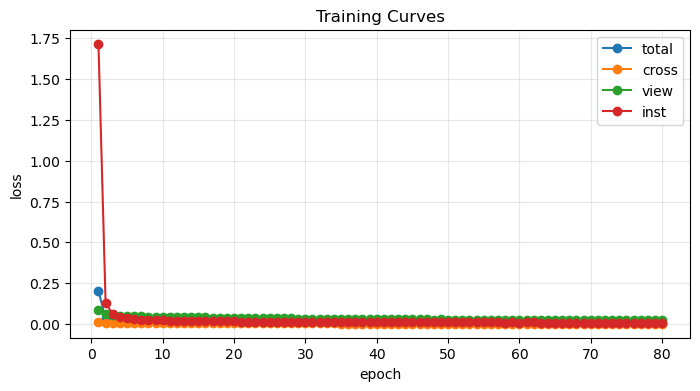

In [28]:
plt.figure(figsize=(8, 4))
for column, label in [
    ("avg_loss", "total"),
    ("avg_cross_loss", "cross"),
    ("avg_view_loss", "view"),
    ("avg_inst_loss", "inst"),
]:
    plt.plot(train_history["epoch"], train_history[column], marker="o", label=label)

plt.title("Training Curves")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 9) Embedding Build and Retrieval

After training, encode the validation split and retrieve neighbors by cosine similarity on `song_embedding`.

Notebook 7 keeps notebook 6's retrieval story and its PNG-based injection path for held-out encoding, while changing the training objective to balance audio and semantic structure.


In [29]:
def parse_tag_list(value) -> list[str]:
    # Use one tag parser for reranking, examples, and quick metrics so these cells stay consistent.
    if isinstance(value, (list, tuple, set)):
        return [str(v).strip() for v in value if str(v).strip()]
    if isinstance(value, np.ndarray):
        return [str(v).strip() for v in value.tolist() if str(v).strip()]
    if isinstance(value, str):
        return [v.strip() for v in value.split(",") if v.strip()]
    return []


def parse_tag_set(value) -> set[str]:
    return set(parse_tag_list(value))


def tag_jaccard(a_tags: set[str], b_tags: set[str]) -> float:
    union = a_tags | b_tags
    return len(a_tags & b_tags) / len(union) if union else 0.0


@torch.no_grad()
def build_song_embeddings(model, loader, device):
    # Encode the full validation split once, then reuse the cached matrix for retrieval and metrics.
    model.eval()
    track_ids = []
    song_embeddings = []
    mix_embeddings = []
    stem_embeddings = []

    for batch in loader:
        mix = batch["mix"].to(device)
        stems = batch["stems"].to(device)
        out = model(mix, stems)

        track_ids.extend(batch["track_id"])
        song_embeddings.append(F.normalize(out["song_embedding"], dim=1, eps=1e-8).cpu())
        mix_embeddings.append(F.normalize(out["mix_embedding"], dim=1, eps=1e-8).cpu())
        stem_embeddings.append(F.normalize(out["fused_stem_embedding"], dim=1, eps=1e-8).cpu())

    return {
        "track_ids": track_ids,
        "song_embeddings": torch.cat(song_embeddings, dim=0).numpy(),
        "mix_embeddings": torch.cat(mix_embeddings, dim=0).numpy(),
        "stem_embeddings": torch.cat(stem_embeddings, dim=0).numpy(),
    }


def topk_cosine(embeddings, query_vec, k=10, exclude_idx=None):
    emb = torch.as_tensor(embeddings, dtype=torch.float32)
    q = torch.as_tensor(query_vec, dtype=torch.float32)
    sims = emb @ q

    if exclude_idx is not None:
        sims[exclude_idx] = float("-inf")

    max_k = emb.shape[0] - (1 if exclude_idx is not None else 0)
    top_vals, top_idx = torch.topk(sims, k=min(int(k), int(max_k)), largest=True, sorted=True)
    return top_idx.cpu().numpy(), top_vals.cpu().numpy()


def recommend_from_query(embedding_df, emb, query_spotify_id, k=10):
    query_idx = int(embedding_df.index[embedding_df["spotify_id"] == query_spotify_id][0])
    idx, scores = topk_cosine(emb, emb[query_idx], k=k, exclude_idx=query_idx)
    recs = embedding_df.iloc[idx].copy()
    recs["similarity"] = scores
    return query_idx, emb[query_idx], recs


def recommend_from_query_reranked(embedding_df, emb, query_spotify_id, k=10, candidate_pool=100):
    candidate_pool = max(int(candidate_pool), int(k))
    query_idx, _, recs = recommend_from_query(embedding_df, emb, query_spotify_id, k=candidate_pool)
    qrow = embedding_df.iloc[query_idx]
    qtags = parse_tag_set(qrow.get("clean_tags", []))

    recs = recs.copy()
    recs["tag_jaccard"] = recs["clean_tags"].apply(lambda t: tag_jaccard(qtags, parse_tag_set(t)))
    recs["year_bonus"] = -recs["year"].apply(
        lambda y: 0.0 if pd.isna(y) or pd.isna(qrow.get("year", np.nan)) else abs(float(y) - float(qrow["year"]))
    )
    recs["artist_penalty"] = (recs["artist"] == qrow["artist"]).astype(float)

    recs["rerank_score"] = (
        recs["similarity"]
        + CFG["rerank_tag_weight"] * recs["tag_jaccard"]
        + CFG["rerank_year_weight"] * recs["year_bonus"]
        - CFG["rerank_artist_repeat_penalty"] * recs["artist_penalty"]
    )
    recs = recs.sort_values("rerank_score", ascending=False).head(k)
    return query_idx, emb[query_idx], recs


def reranking_enabled(cfg):
    return any(
        float(cfg[key]) != 0.0
        for key in ["rerank_tag_weight", "rerank_year_weight", "rerank_artist_repeat_penalty"]
    )


def show_example_queries(embedding_df, emb, count=3, k=5, seed=42):
    eligible = embedding_df.reset_index(drop=True)
    if len(eligible) == 0 or count <= 0:
        return

    sample = eligible.sample(min(int(count), len(eligible)), random_state=seed).reset_index(drop=True)
    for _, row in sample.iterrows():
        print(f"example query: {row['artist']} - {row['name']}")
        print("clean tags:", row.get("clean_tags", []))
        _, _, recs = recommend_from_query(embedding_df, emb, row["spotify_id"], k=k)
        display(recs[["artist", "name", "spotify_id", "similarity", "clean_tags"]])
        print()


In [30]:
embedding_out = build_song_embeddings(model, eval_loader, device)
track_ids = embedding_out["track_ids"]
song_embeddings = embedding_out["song_embeddings"]
mix_embeddings = embedding_out["mix_embeddings"]
stem_embeddings = embedding_out["stem_embeddings"]

embedding_df = val_df[["spotify_id", "artist", "name", "tags", "clean_tags", "year", "has_semantic_teacher"]].copy()
embedding_df = embedding_df.set_index("spotify_id").loc[track_ids].reset_index()

query_id = CFG["query_spotify_id"]
if query_id not in set(embedding_df["spotify_id"]):
    query_id = embedding_df.iloc[0]["spotify_id"]
    print("CFG query id not found in validation split; using first validation track instead:", query_id)

_, _, recs_base = recommend_from_query(embedding_df, song_embeddings, query_id, k=10)
recs_rerank = None
if reranking_enabled(CFG):
    _, _, recs_rerank = recommend_from_query_reranked(embedding_df, song_embeddings, query_id, k=10, candidate_pool=100)

query_row = embedding_df.loc[embedding_df["spotify_id"] == query_id].iloc[0]
print("query:", query_row["artist"], "-", query_row["name"])
print("query clean tags:", query_row["clean_tags"])
print()
print("Baseline top-10")
display(recs_base[["artist", "name", "spotify_id", "similarity"]])

if recs_rerank is not None:
    print()
    print("Optional reranked top-10")
    display(recs_rerank[["artist", "name", "spotify_id", "similarity", "rerank_score"]])
else:
    print()
    print("Optional reranking is disabled because all rerank weights are 0.0.")

print()
print("Qualitative spot-check queries")
show_example_queries(
    embedding_df,
    song_embeddings,
    count=CFG["example_query_count"],
    k=CFG["example_top_k"],
    seed=CFG["metrics_sample_seed"],
)


CFG query id not found in validation split; using first validation track instead: 0m44L9w4l6ClNcU48IZBAZ
query: Pink Floyd - What Do You Want From Me
query clean tags: ['classic_rock', 'progressive_rock', 'psychedelic', 'psychedelic_rock']

Baseline top-10


,artist,name,spotify_id,similarity
333,Andrew Bird,Armchairs,0PvhPmZmYIswNmYAPztYxn,0.967056
1250,Scorpions,Believe In Love,05pJDW4k4Ab6Vl1PqoJsPE,0.956923
536,My Morning Jacket,Gideon,1gAY6VkofvNgDDj0E7vtdi,0.952571
252,Mac DeMarco,Annie,251isBi3o3xoGh1N5mn4We,0.949944
1037,Dream Theater,Anna Lee,5rielSbAmN45G7MzfNt3KP,0.948372
20,The Allman Brothers Band,Whipping Post,047WuSeTuGLhMAFM34mQjB,0.946475
1065,Porcupine Tree,Nine Cats,0Bf6Dsfan3OVN0RY94NNH6,0.946298
326,Sufjan Stevens,Sister,4BbNWADUUZI4SNq6wk6d5A,0.945864
66,Jimi Hendrix,Long Hot Summer Night,1HFj7yC7uZfqjWuoH6DO9r,0.945110
1266,Mötley Crüe,You're All I Need,09An26ahmYAheYDNztdBns,0.944435



Optional reranking is disabled because all rerank weights are 0.0.

Qualitative spot-check queries
example query: Genesis - The Lamb Lies Down on Broadway
clean tags: ['progressive_rock', '70s']


,artist,name,spotify_id,similarity,clean_tags
516,Beach House,Wishes,2IxB0hw4LOQbFOwOb7zqTT,0.933973,"[indie_rock, american, beautiful]"
55,Derek and the Dominos,Bell Bottom Blues,0kzuHiTkK8HLpg4sG8Uzky,0.931516,"[classic_rock, blues, 70s, guitar, blues_rock]"
954,Tears for Fears,Pale Shelter,23PdXmRgPZ7Fq9wURvaZX0,0.930396,"[80s, new_wave, synthpop]"
1091,The Mars Volta,In Absentia,2NfeWnbJHO6MnkO2fX3p7V,0.929888,"[alternative_rock, progressive_rock, psychedel..."
383,David Gray,Say Hello Wave Goodbye,0eUfaEi18FD4WPPb44nL4B,0.928890,"[folk, singer_songwriter, acoustic, male_vocal..."



example query: Dead Man's Bones - My Body's a Zombie for You
clean tags: ['folk', 'downtempo', '00s']


,artist,name,spotify_id,similarity,clean_tags
345,Flight of the Conchords,Bowie,0r0270KL38hMWxcrQYldJU,0.971682,[folk]
1008,Soft Cell,Sex Dwarf,03DtZyPrG98h4Z3QwvfDgQ,0.966541,"[80s, new_wave, synthpop]"
315,Elliott Smith,Everything Means Nothing To Me,0u59AlLY8QrqIsi81vJIra,0.965904,"[indie, folk, indie_rock, singer_songwriter, a..."
282,Gnarls Barkley,Open Book,1bUz9AuPuSpHJ2a6M2iOYH,0.965352,"[experimental, soul, hip_hop, funk, trip_hop, ..."
331,Joshua Radin,These Photographs,0peo1wZlY73ZoGCUh6MXnZ,0.964066,"[indie, folk, singer_songwriter, acoustic, bea..."



example query: Anaal Nathrakh - Lama Sabachthani
clean tags: ['black_metal', 'grindcore']


,artist,name,spotify_id,similarity,clean_tags
812,1349,To Rottendom,223vd2rdMKcvXWQHhB22Am,0.990304,[black_metal]
838,1349,Manifest,2D7fSvG1kyC482JrPJZ89n,0.989155,[black_metal]
860,Watain,De Profundis,4vo2FJqXYGWRifwqcJIGN2,0.988990,[black_metal]
1146,Amon Amarth,Avenger,0mj6gGV4JFJ3UCEMNjytZD,0.987931,"[death_metal, melodic_death_metal]"
1208,Neaera,Spearheading the Spawn,2EYk4joWQvkYGy18XQblxw,0.987826,"[death_metal, metalcore, german, melodic_death..."


## 10) Lightweight Quality Checks

These are still quick held-out checks:
- `artist_hit@10`
- `tag_overlap_hit@10`
- `semantic_teacher_coverage`

They remain useful sanity checks, and notebook 7 also includes a few qualitative spot-check queries so the final notebook can still be inspected by ear later, not only through proxy metrics.


In [31]:
def sample_eval_df(embedding_df, max_queries=None, seed=42):
    # Quick metrics can subsample queries so this section stays fast on larger catalogs.
    if len(embedding_df) == 0 or max_queries is None or max_queries >= len(embedding_df):
        return embedding_df.reset_index(drop=True)
    if max_queries <= 0:
        return embedding_df.iloc[0:0].copy()
    return embedding_df.sample(max_queries, random_state=seed).reset_index(drop=True)


def queries_with_clean_tags(eval_df):
    return eval_df[eval_df["clean_tags"].apply(lambda tags: len(parse_tag_set(tags)) > 0)].reset_index(drop=True)


def artist_hit_at_k(embedding_df, emb, k=10, max_queries=None, seed=42):
    eval_df = sample_eval_df(embedding_df, max_queries=max_queries, seed=seed)
    if len(eval_df) == 0:
        return float("nan"), 0

    hits = []
    for _, row in eval_df.iterrows():
        _, _, recs = recommend_from_query(embedding_df, emb, row["spotify_id"], k=k)
        hits.append(float((recs["artist"] == row["artist"]).any()))
    return float(np.mean(hits)), len(eval_df)


def tag_overlap_hit_at_k(embedding_df, emb, k=10, max_queries=None, seed=42):
    eval_df = queries_with_clean_tags(sample_eval_df(embedding_df, max_queries=max_queries, seed=seed))
    if len(eval_df) == 0:
        return float("nan"), 0

    hits = []
    for _, row in eval_df.iterrows():
        qtags = parse_tag_set(row.get("clean_tags", []))
        _, _, recs = recommend_from_query(embedding_df, emb, row["spotify_id"], k=k)
        overlap = any(len(qtags & parse_tag_set(tags)) > 0 for tags in recs["clean_tags"].tolist())
        hits.append(float(overlap))
    return float(np.mean(hits)), len(eval_df)


def semantic_teacher_coverage(embedding_df):
    # Coverage answers: how much of the validation split actually has a tag-teacher set from the notebooks 4-6 setup?
    return float(embedding_df["has_semantic_teacher"].mean())


artist_hit_10, artist_query_count = artist_hit_at_k(
    embedding_df,
    song_embeddings,
    k=10,
    max_queries=CFG["metrics_max_queries"],
    seed=CFG["metrics_sample_seed"],
)
tag_overlap_hit_10, tag_overlap_query_count = tag_overlap_hit_at_k(
    embedding_df,
    song_embeddings,
    k=10,
    max_queries=CFG["metrics_max_queries"],
    seed=CFG["metrics_sample_seed"],
)

metrics = pd.DataFrame(
    {
        "metric": ["artist_hit@10", "tag_overlap_hit@10", "semantic_teacher_coverage"],
        "value": [
            artist_hit_10,
            tag_overlap_hit_10,
            semantic_teacher_coverage(embedding_df),
        ],
        "queries": [artist_query_count, tag_overlap_query_count, len(embedding_df)],
    }
)
metrics

print(f"artist_hit@10 queries evaluated: {artist_query_count}")
print(f"tag_overlap_hit@10 queries evaluated: {tag_overlap_query_count}")


artist_hit@10 queries evaluated: 1447
tag_overlap_hit@10 queries evaluated: 1438


## Appendix: Optional Metadata Reranking

This stays outside the main retrieval path.

If you later enable nonzero rerank weights, the notebook can rescore a cosine candidate pool with three metadata terms:
- $J_{\mathrm{tag}}$: clean-tag overlap,
- $b_{\mathrm{year}}$: closer release years score higher,
- $p_{\mathrm{artist}}$: same-artist penalty.

Rerank score:
$$
s_{\mathrm{rerank}} = s_{\mathrm{cos}} + w_t J_{\mathrm{tag}} + w_y b_{\mathrm{year}} - w_a p_{\mathrm{artist}}
$$

By default, $w_t = w_y = w_a = 0$, so the notebook story stays focused on baseline cosine retrieval from the learned embedding.


## Run Summary

- `CFG` is the single control panel for the run.
- Training uses `data/processed/train.parquet`.
- Retrieval and quick checks use `data/processed/val.parquet`.
- Cross-song supervision uses a balanced blend: a frozen compact PNG-based audio teacher provides `50%` of the target and the tag teacher inherited from notebooks 4-6 provides the other `50%` when available.
- Injection follows notebook 6's PNG spectrogram path, while notebook 7 changes the supervision to balance audio and semantic structure.
- The small contrastive term is same-song paired-view alignment on the final song embedding.
- Metadata reranking stays optional and disabled by default.


## 11) Artifact Saving

Save the model, the validation-set embeddings, and a small manifest so the run can be reloaded later without relying on anything outside this notebook.


In [32]:
# Save artifacts for reuse.
checkpoint_path = OUTPUT_DIR / "checkpoint.pt"
embeddings_path = OUTPUT_DIR / "embeddings.npz"
manifest_path = OUTPUT_DIR / "run_manifest.json"

def _json_safe(value):
    if isinstance(value, dict):
        return {str(k): _json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_safe(v) for v in value]
    if isinstance(value, np.ndarray):
        return [_json_safe(v) for v in value.tolist()]
    if isinstance(value, np.generic):
        return _json_safe(value.item())
    if isinstance(value, float) and not np.isfinite(value):
        return None
    return value

torch.save(
    # Save enough to rebuild the model and reuse the held-out embedding matrix later.
    {
        "model_state_dict": model.state_dict(),
        "embedding_dim": CFG["embedding_dim"],
        "projection_dim": CFG["projection_dim"],
        "model_init_kwargs": {
            "embedding_dim": CFG["embedding_dim"],
            "projection_dim": CFG["projection_dim"],
            "pretrained": CFG["pretrained"],
            "imagenet_input_norm": model.imagenet_input_norm,
            "fusion_alpha_init": CFG["fusion_alpha_init"],
            "drum_alpha_init": CFG["drum_alpha_init"],
            "num_stems": model.num_stems,
            "stem_dropout_prob": model.stem_dropout_prob,
            "harmonic_indices": list(model.harmonic_indices),
            "drum_index": model.drum_index,
        },
        "cfg": CFG,
        "train_history": train_history.to_dict(orient="records"),
    },
    checkpoint_path,
)

np.savez(
    embeddings_path,
    song_embeddings=song_embeddings.astype(np.float32),
    mix_embeddings=mix_embeddings.astype(np.float32),
    stem_embeddings=stem_embeddings.astype(np.float32),
    spotify_id=np.asarray(track_ids, dtype=str),
)

manifest = {
    "saved_at": datetime.now().isoformat(timespec="seconds"),
    "experiment_name": CFG["experiment_name"],
    "reference_note": "Final late-fusion song embedding trained against a 50/50 blend of frozen PNG-based audio similarity and the tag-set teacher carried over from notebooks 4-6, with same-song paired-view regularization.",
    "run_label": CFG["run_label"],
    "checkpoint_path": str(checkpoint_path),
    "embeddings_path": str(embeddings_path),
    "validation_split_path": str((DATA_DIR / "processed" / "val.parquet").resolve()),
    "num_saved_tracks": int(len(track_ids)),
    "metrics": metrics.to_dict(orient="records"),
}
manifest_path.write_text(json.dumps(_json_safe(manifest), indent=2))

print("saved checkpoint:", checkpoint_path)
print("saved embeddings:", embeddings_path)
print("saved manifest:", manifest_path)

saved checkpoint: C:\Users\Juan\Documents\GitHub\dl-song-recommender\data\processed\model_runs\07_Resnet18_audio_centric_blended_teacher\checkpoint.pt
saved embeddings: C:\Users\Juan\Documents\GitHub\dl-song-recommender\data\processed\model_runs\07_Resnet18_audio_centric_blended_teacher\embeddings.npz
saved manifest: C:\Users\Juan\Documents\GitHub\dl-song-recommender\data\processed\model_runs\07_Resnet18_audio_centric_blended_teacher\run_manifest.json


## 12) Load Saved Artifacts Later

Use this in a fresh kernel to reload the saved model and saved validation embeddings from this notebook's run directory.


In [33]:
# Fresh-kernel reload cell: mirror the minimal model code needed for inference.
import json
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from pathlib import Path
from torchvision.models import resnet18

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "src").exists() and ROOT_DIR.parent.exists():
    ROOT_DIR = ROOT_DIR.parent
SRC_DIR = ROOT_DIR / "src"
if SRC_DIR.exists() and str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

default_run_label = "07_Resnet18_audio_focused_infonce"
run_label = CFG.get("run_label", default_run_label) if "CFG" in globals() else default_run_label
data_dir = DATA_DIR if "DATA_DIR" in globals() else (ROOT_DIR / "data").resolve()

output_dir = (data_dir / "processed" / "model_runs" / run_label).resolve()
load_checkpoint_path = output_dir / "checkpoint.pt"
load_embeddings_path = output_dir / "embeddings.npz"
load_manifest_path = output_dir / "run_manifest.json"

loaded_val_df = pd.read_parquet(data_dir / "processed" / "val.parquet")
loaded_manifest = json.loads(load_manifest_path.read_text()) if load_manifest_path.exists() else None
if loaded_manifest is not None:
    print("loaded manifest:", load_manifest_path)

loaded_song_embeddings = None
loaded_mix_embeddings = None
loaded_stem_embeddings = None
loaded_track_ids = None

if load_embeddings_path.exists():
    loaded_npz = np.load(load_embeddings_path)
    loaded_song_embeddings = loaded_npz["song_embeddings"]
    loaded_mix_embeddings = loaded_npz["mix_embeddings"]
    loaded_stem_embeddings = loaded_npz["stem_embeddings"]
    loaded_track_ids = loaded_npz["spotify_id"].astype(str).tolist()
    print("loaded embeddings:", load_embeddings_path)
    print("song embeddings shape:", loaded_song_embeddings.shape)
    print("num track ids:", len(loaded_track_ids))
else:
    print("embeddings file not found:", load_embeddings_path)

if "ProjectionHead" not in globals():
    # Define the classes inline so this cell works without rerunning the training section.
    class ProjectionHead(nn.Module):
        def __init__(self, input_dim: int, projection_dim: int):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, input_dim),
                nn.ReLU(inplace=True),
                nn.Linear(input_dim, projection_dim),
            )

        def forward(self, x):
            return self.net(x)

if "StemLateFusionResNet18" not in globals():
    class StemLateFusionResNet18(nn.Module):
        def __init__(
            self,
            embedding_dim=64,
            projection_dim=64,
            pretrained=False,
            imagenet_input_norm=None,
            fusion_alpha_init=0.7,
            drum_alpha_init=0.3,
            num_stems=4,
            stem_dropout_prob=0.1,
            harmonic_indices=(0, 2, 3),
            drum_index=1,
        ):
            super().__init__()
            backbone = resnet18(weights=None)
            in_features = backbone.fc.in_features
            backbone.fc = nn.Linear(in_features, embedding_dim)

            self.encoder = backbone
            self.projection_head = ProjectionHead(embedding_dim, projection_dim)
            if imagenet_input_norm is None:
                imagenet_input_norm = pretrained
            self.imagenet_input_norm = bool(imagenet_input_norm)
            self.register_buffer(
                "imagenet_mean",
                torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 3, 1, 1),
                persistent=False,
            )
            self.register_buffer(
                "imagenet_std",
                torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 3, 1, 1),
                persistent=False,
            )

            self.fusion_alpha_logit = nn.Parameter(torch.tensor(fusion_alpha_init, dtype=torch.float32).logit())
            self.drum_alpha_logit = nn.Parameter(torch.tensor(drum_alpha_init, dtype=torch.float32).logit())
            self.num_stems = int(num_stems)
            self.harmonic_indices = tuple(int(idx) for idx in harmonic_indices)
            self.drum_index = int(drum_index)
            self.stem_logits = nn.Parameter(torch.zeros(self.num_stems, dtype=torch.float32))
            self.harmonic_logits = nn.Parameter(torch.zeros(len(self.harmonic_indices), dtype=torch.float32))
            self.register_buffer(
                "harmonic_index_tensor",
                torch.tensor(self.harmonic_indices, dtype=torch.long),
                persistent=False,
            )
            self.stem_dropout_prob = float(stem_dropout_prob)

        def _encode_inputs(self, x):
            if x.shape[1] == 1:
                x = x.repeat(1, 3, 1, 1)
            if self.imagenet_input_norm:
                x = (x - self.imagenet_mean) / self.imagenet_std
            return self.encoder(x)

        def forward(self, mix, stems):
            batch_size, num_stems, channels, height, width = stems.shape
            mix_embedding = self._encode_inputs(mix)
            stem_inputs = stems.reshape(batch_size * num_stems, channels, height, width)
            stem_embeddings = self._encode_inputs(stem_inputs).reshape(batch_size, num_stems, -1)
            stem_embeddings = F.normalize(stem_embeddings, dim=2, eps=1e-8)

            stem_weights = torch.softmax(self.stem_logits, dim=0).unsqueeze(0).expand(batch_size, -1)
            stem_weights = stem_weights / stem_weights.sum(dim=1, keepdim=True).clamp_min(1e-8)

            harmonic_stems = stem_embeddings[:, self.harmonic_index_tensor, :]
            harmonic_weights = torch.softmax(self.harmonic_logits, dim=0).unsqueeze(0).expand(batch_size, -1)
            harmonic_weights = harmonic_weights * stem_weights[:, self.harmonic_index_tensor]
            harmonic_weights = torch.where(
                harmonic_weights.sum(dim=1, keepdim=True) == 0,
                torch.ones_like(harmonic_weights),
                harmonic_weights,
            )
            harmonic_weights = harmonic_weights / harmonic_weights.sum(dim=1, keepdim=True).clamp_min(1e-8)
            harmonic_embedding = torch.sum(harmonic_stems * harmonic_weights.unsqueeze(-1), dim=1)
            drum_embedding = stem_embeddings[:, self.drum_index, :] * stem_weights[:, self.drum_index].unsqueeze(-1)

            mix_embedding = F.normalize(mix_embedding, dim=1, eps=1e-8)
            harmonic_embedding = F.normalize(harmonic_embedding, dim=1, eps=1e-8)
            drum_embedding = F.normalize(drum_embedding, dim=1, eps=1e-8)

            alpha_h = torch.sigmoid(self.fusion_alpha_logit)
            alpha_d = torch.sigmoid(self.drum_alpha_logit)
            song_embedding = F.normalize(
                mix_embedding + alpha_h * harmonic_embedding + alpha_d * drum_embedding,
                dim=1,
                eps=1e-8,
            )

            harmonic_projection = self.projection_head(harmonic_embedding)
            return {
                "song_embedding": song_embedding,
                "mix_embedding": mix_embedding,
                "fused_stem_embedding": harmonic_embedding,
                "harmonic_embedding": harmonic_embedding,
                "drum_embedding": drum_embedding,
                "mix_projection": self.projection_head(mix_embedding),
                "harmonic_projection": harmonic_projection,
                "stem_projection": harmonic_projection,
            }

loaded_model = None
if load_checkpoint_path.exists():
    device = torch.device(CFG["device"] if "CFG" in globals() else ("cuda" if torch.cuda.is_available() else "cpu"))
    checkpoint = torch.load(load_checkpoint_path, map_location=device, weights_only=False)
    model_init_kwargs = checkpoint.get("model_init_kwargs", {}).copy()
    if not model_init_kwargs:
        checkpoint_cfg = checkpoint.get("cfg", {})
        model_init_kwargs = {
            "embedding_dim": int(checkpoint["embedding_dim"]),
            "projection_dim": int(checkpoint["projection_dim"]),
            "pretrained": False,
            "imagenet_input_norm": bool(checkpoint_cfg.get("pretrained", False)),
        }
    else:
        model_init_kwargs["pretrained"] = False
    loaded_model = StemLateFusionResNet18(**model_init_kwargs).to(device)
    loaded_model.load_state_dict(checkpoint["model_state_dict"])
    loaded_model.eval()
    print("loaded model:", load_checkpoint_path)
else:
    print("checkpoint not found:", load_checkpoint_path)

loaded manifest: C:\Users\Juan\Documents\GitHub\dl-song-recommender\data\processed\model_runs\07_Resnet18_audio_centric_blended_teacher\run_manifest.json
loaded embeddings: C:\Users\Juan\Documents\GitHub\dl-song-recommender\data\processed\model_runs\07_Resnet18_audio_centric_blended_teacher\embeddings.npz
song embeddings shape: (1447, 64)
num track ids: 1447
loaded model: C:\Users\Juan\Documents\GitHub\dl-song-recommender\data\processed\model_runs\07_Resnet18_audio_centric_blended_teacher\checkpoint.pt


## 13) Quick Eval After Loading

Run this right after the load cell in a fresh kernel. It uses the saved validation embeddings for baseline cosine retrieval only.


In [34]:
def _topk_cosine_torch(embeddings, query_vec, k=10, exclude_idx=None):
    emb = torch.as_tensor(embeddings, dtype=torch.float32)
    q = torch.as_tensor(query_vec, dtype=torch.float32)
    sims = emb @ q
    if exclude_idx is not None:
        sims[exclude_idx] = float("-inf")
    k = min(int(k), int(emb.shape[0] - (1 if exclude_idx is not None else 0)))
    vals, idx = torch.topk(sims, k=k, largest=True, sorted=True)
    return idx.cpu().numpy(), vals.cpu().numpy()


def _recommend(df_in, emb, qid, k=10):
    qidx = int(df_in.index[df_in["spotify_id"] == qid][0])
    idx, vals = _topk_cosine_torch(emb, emb[qidx], k=k, exclude_idx=qidx)
    out = df_in.iloc[idx].copy()
    out["similarity"] = vals
    return out


if loaded_track_ids is None or loaded_song_embeddings is None:
    print("No loaded embeddings available for quick eval.")
else:
    loaded_embedding_df = loaded_val_df[["spotify_id", "artist", "name", "tags", "year"]].copy()
    # Reorder the saved rows to match the saved embedding matrix exactly.
    loaded_embedding_df = loaded_embedding_df.set_index("spotify_id").loc[loaded_track_ids].reset_index()

    query_id = CFG["query_spotify_id"] if "CFG" in globals() else loaded_embedding_df.iloc[0]["spotify_id"]
    if query_id not in set(loaded_embedding_df["spotify_id"]):
        query_id = loaded_embedding_df.iloc[0]["spotify_id"]
        print("Configured query id not found in loaded validation split; using first validation track instead:", query_id)

    recs_loaded = _recommend(loaded_embedding_df, loaded_song_embeddings, query_id, k=10)
    print("query id:", query_id)
    display(recs_loaded[["artist", "name", "spotify_id", "similarity"]])


Configured query id not found in loaded validation split; using first validation track instead: 0m44L9w4l6ClNcU48IZBAZ
query id: 0m44L9w4l6ClNcU48IZBAZ


,artist,name,spotify_id,similarity
333,Andrew Bird,Armchairs,0PvhPmZmYIswNmYAPztYxn,0.967056
1250,Scorpions,Believe In Love,05pJDW4k4Ab6Vl1PqoJsPE,0.956923
536,My Morning Jacket,Gideon,1gAY6VkofvNgDDj0E7vtdi,0.952571
252,Mac DeMarco,Annie,251isBi3o3xoGh1N5mn4We,0.949944
1037,Dream Theater,Anna Lee,5rielSbAmN45G7MzfNt3KP,0.948372
20,The Allman Brothers Band,Whipping Post,047WuSeTuGLhMAFM34mQjB,0.946475
1065,Porcupine Tree,Nine Cats,0Bf6Dsfan3OVN0RY94NNH6,0.946298
326,Sufjan Stevens,Sister,4BbNWADUUZI4SNq6wk6d5A,0.945864
66,Jimi Hendrix,Long Hot Summer Night,1HFj7yC7uZfqjWuoH6DO9r,0.945110
1266,Mötley Crüe,You're All I Need,09An26ahmYAheYDNztdBns,0.944435
